In [1]:
import numpy as np
from IQAEBinom import IQAEBinom
import matplotlib.pyplot as plt
import pickle
from BiasCorrection import BiasExact
import datetime

In [2]:
epsilon = 0.001
nEstim = 10000
alpha = 0.05
nShotUnit = 1

In [3]:
p = np.pi / 8 + 0.001

In [4]:
alpha = 0.05 / nEstim
results = np.array([])

for i in range(nEstim):
    result = IQAEBinom(p, epsilon, alpha, nShotUnit, confint_method="chernoff")
    results = np.append(results, result)

In [5]:
with open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/results_IQAE_pTrue=piOver8+0.001_epsilon0001_alpha005.dat", 'wb') as f:
    pickle.dump(results, f) 

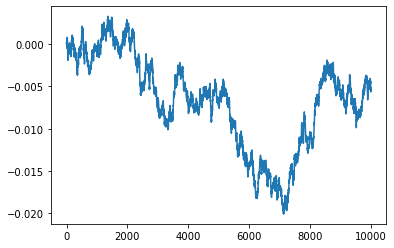

In [6]:
errs = [r["Estimate"] - p for r in results]

ax = plt.gca()
plt.plot(np.array(errs).cumsum())
plt.show()

In [7]:
print(np.mean(errs))
print(np.std(errs) / np.sqrt(nEstim))

-5.314267311873233e-07
1.6663860220971798e-06


In [8]:
results[0]

{'Estimate': 0.3937815993493975,
 'TotalOracleCalls': 56432,
 'nGrover': [0, 1, 6, 14, 29, 65, 131, 271],
 'nShots': [383, 549, 95, 91, 91, 63, 66, 36],
 'n1s': [158, 444, 36, 45, 53, 34, 27, 18],
 'thetaIntervals': [[0, 1.5707963267948966],
  [0.5248282268792542, 0.8596707917783968],
  [0.6061960710671169, 0.7248623100124187],
  [0.6502699455964164, 0.7034584725234156],
  [0.6656454038655947, 0.6880138263810938],
  [0.6716411361246334, 0.6826346052197774],
  [0.6749628327823827, 0.6808449675478705],
  [0.6769421249261484, 0.6797954884270054],
  [0.6773895570575564, 0.6793387620341682]],
 'ampSqIntervals': [[0, 1],
  [0.2510654907439335, 0.5739997834075026],
  [0.3246098665768188, 0.43961193096319223],
  [0.36651071345692077, 0.41842658516201214],
  [0.3813888553625267, 0.40323020601052983],
  [0.38722182998104826, 0.3979583946710194],
  [0.3904603918336743, 0.39620707990640197],
  [0.3923924544018642, 0.39518069118325044],
  [0.39282944473607734, 0.3947341575287854]]}

(array([0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+01, 1.290e+02, 7.300e+01, 4.200e+01,
        1.100e+01, 2.000e+00, 1.030e+02, 2.580e+02, 4.010e+02, 1.233e+03,
        6.150e+02, 4.720e+02, 1.130e+03, 1.421e+03, 1.343e+03, 9.550e+02,
        4.950e+02, 4.570e+02, 1.820e+02, 1.180e+02, 2.340e+02, 8.100e+01,
        1.190e+02, 5.600e+01, 1.100e+01, 2.200e+01, 6.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 3.000e+00, 0.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 3.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([100., 110., 120., 130., 140., 150., 160., 170., 180., 190., 200.,
        210., 220., 230., 240., 250., 260., 270., 280., 290., 300., 310.,
        320., 330., 340., 350., 360., 370., 380., 390., 400., 410., 420.,
        430., 440., 450., 460., 470.

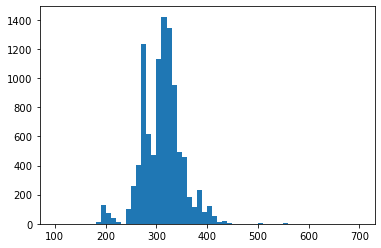

In [9]:
plt.hist([r["nGrover"][-1] for r in results], range=(100,700), bins=60)

(array([2.350e+02, 3.200e+01, 1.360e+02, 2.000e+03, 2.845e+03, 9.880e+02,
        1.101e+03, 9.420e+02, 5.500e+02, 3.780e+02, 2.460e+02, 2.260e+02,
        1.510e+02, 8.500e+01, 3.200e+01, 2.300e+01, 5.000e+00, 9.000e+00,
        4.000e+00, 7.000e+00, 2.000e+00, 2.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00]),
 array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
         55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
        110., 115., 120., 125., 130., 135., 140., 145., 150.]),
 <BarContainer object of 30 artists>)

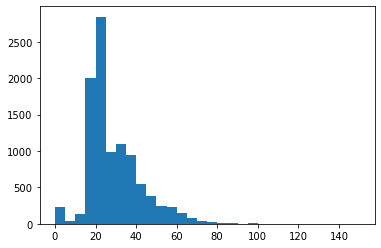

In [10]:
plt.hist([r["nShots"][-1] for r in results], range=(0,150), bins=30)

(array([2.400e+02, 5.050e+02, 7.860e+02, 8.860e+02, 4.520e+02, 2.850e+02,
        1.003e+03, 1.684e+03, 1.265e+03, 1.059e+03, 6.500e+02, 3.080e+02,
        2.280e+02, 1.730e+02, 1.040e+02, 9.000e+01, 5.000e+01, 5.700e+01,
        4.700e+01, 4.000e+01, 2.300e+01, 2.400e+01, 7.000e+00, 7.000e+00,
        1.000e+01, 1.000e+00, 4.000e+00, 2.000e+00, 0.000e+00, 0.000e+00,
        4.000e+00, 1.000e+00, 3.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00]),
 array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,
         22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,
         44.,  46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,
         66.,  68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,
         88.,  90.,  92.,  94.,  96.,  98., 100.]),
 <BarContainer object of 50 

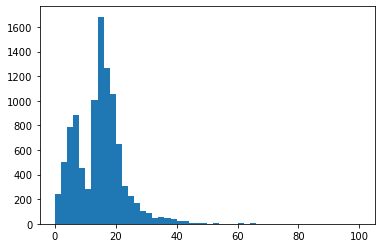

In [11]:
plt.hist([r["n1s"][-1] for r in results], range=(0,100), bins=50)

final p1はunbiasedになってるか？

(array([   0.,    3.,   26.,   27.,   31.,   90.,   72.,  119.,  184.,
          64.,  199.,  191.,  223.,  313.,  216.,  352.,  234.,  392.,
         235.,  215.,  289.,  238.,  271.,  249.,  205., 1018.,  223.,
         264.,  235.,  158.,  453.,  291.,  220.,  210.,  487.,  186.,
         285.,  214.,  266.,  219.,  168.,  129.,  226.,   69.,   50.,
         117.,   22.,   36.,   14.,    2.]),
 array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
        0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
        0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
        0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ]),
 <BarContainer object of 50 artists>)

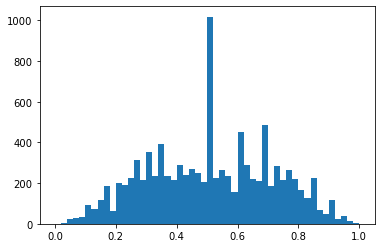

In [12]:
plt.hist([r["n1s"][-1] / r["nShots"][-1] for r in results], range=(0,1), bins=50)

In [13]:
thetaTrue = np.arcsin(np.sqrt(p))
p1FinalErr = [r["n1s"][-1] / r["nShots"][-1] - np.sin((2 * r["nGrover"][-1] + 1) * thetaTrue) ** 2 for r in results]

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          4.,   1.,   1.,   4.,   2.,   8.,   6.,   5.,  14.,   5.,  16.,
         20.,  27.,  33.,  41.,  27.,  30.,  50.,  93.,  35.,  52., 140.,
         98., 133., 139., 277., 152., 265., 270., 210., 488., 299., 498.,
        408., 310., 325., 341., 459., 450., 561., 476., 252., 393., 342.,
        194., 175., 427., 309., 183.,  88.,  90., 158., 128.,  87.,  54.,
         74.,  23.,  49.,  59.,  25.,  19.,  16.,   4.,  13.,  11.,  20.,
          6.,   6.,   1.,   2.,   7.,   3.,   1.,   1.,   1.,   0.,   2.,
          1.,   0.,   0.,   1.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]),
 array([-7.00000000e-01, -6.90000000e-01, -6.80000000e

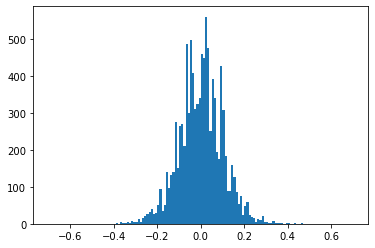

In [14]:
plt.hist(p1FinalErr, range=(-0.7, 0.7), bins=140)

In [15]:
print(np.mean(p1FinalErr))
print(np.std(p1FinalErr) / np.sqrt(len(p1FinalErr)))

4.6221746002044205e-07
0.0009845807511336259


errorの分布

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.,   1.,   0.,   0.,   0.,   0.,   2.,   0.,   5.,
          0.,   5.,   9.,   8.,   3.,   8.,  36.,  41.,   6.,  44.,  57.,
        119.,  68.,  72.,  86., 168., 147., 174., 233., 384., 365., 242.,
        394., 393., 480., 482., 591., 469., 421., 413., 380., 493., 590.,
        341., 295., 396., 229., 283., 184., 193., 122., 133., 101.,  19.,
         66.,  93.,  20.,  24.,  39.,  15.,  11.,  19.,   4.,   4.,   5.,
          4.,   3.,   4.,   1.,   2.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.]),
 array([-1.0e-03, -9.8e-04, -9.6e-04, -9.4e-04, -9.2e-04, -9.0e-04,
        -8.8e-04, -8.6e-04, -8.4e-04, -8.2e-04, -8.0e-04, -7.8e-04,
        -7.6e-04, -7.4e-04, -7.2e-04, -7.0e-04, -6.8e-04, -6.6e-04,
        -6.4e-04, -6.2e-04, -6.0e-04, -5.8e-04, -5.6e-04, -5.4e-04,
        -5.2e-04, -5.0e-04, -4.8e-04, -4.6e-04

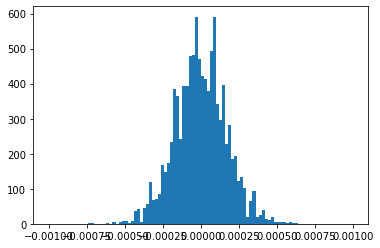

In [16]:
plt.hist(errs, range=(-0.001,0.001), bins=100)